<a href="https://colab.research.google.com/github/vamsidharreddykonapalli-afk/smart-notes-api/blob/main/Week3_EDA_Visualization_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3: Advanced Data Analysis and Visualization in Logistics
Exploratory Data Analysis (EDA) and visualization of a simulated logistics shipment dataset (900 shipments, 4 warehouses, 3 carriers, 4 regions, 10 months).

This notebook:
1. Simulates the dataset (or you can swap in your own CSV)
2. Computes central tendency, distributions, and correlations
3. Produces 6 visualizations with interpretations
4. Summarizes recommendations


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install pandas numpy matplotlib seaborn scipy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", font_scale=1.0)
ACCENT = "#1F4E5F"
PALETTE = ["#1F4E5F", "#3E8E9E", "#8FBFC9"]


## Step 1: Simulate the dataset
If you have your own logistics CSV, skip this cell and load it instead with `pd.read_csv(...)`.

In [3]:
np.random.seed(7)
n = 900

warehouses = ["WH-A", "WH-B", "WH-C", "WH-D"]
carriers = ["FastFreight", "RegionalHaul", "MetroShip"]
regions = ["North", "South", "East", "West"]

dates = pd.date_range("2025-01-01", periods=n, freq="8h")
month_idx = dates.month
seasonal_factor = 1 + 0.35 * np.sin((month_idx - 3) * np.pi / 6) + 0.25 * (month_idx.isin([11, 12])).astype(float)

warehouse_choice = np.random.choice(warehouses, n, p=[0.30, 0.28, 0.24, 0.18])
carrier_choice = np.random.choice(carriers, n, p=[0.40, 0.35, 0.25])
region_choice = np.random.choice(regions, n)

region_base_dist = {"North": 140, "South": 95, "East": 110, "West": 160}
distance_km = np.array([region_base_dist[r] for r in region_choice]) + np.random.normal(0, 25, n)
distance_km = np.clip(distance_km, 10, None)

shipment_volume = np.random.poisson(40 * seasonal_factor).astype(float)
shipment_volume = np.clip(shipment_volume, 1, None)

carrier_speed = {"FastFreight": 1.0, "RegionalHaul": 1.3, "MetroShip": 0.85}
carrier_cost_factor = {"FastFreight": 1.25, "RegionalHaul": 0.9, "MetroShip": 1.05}

base_delivery_time = 1.2 + distance_km / 60
delivery_time_days = np.array([
    base_delivery_time[i] * carrier_speed[carrier_choice[i]] for i in range(n)
]) + np.random.normal(0, 0.6, n)
delivery_time_days = np.clip(delivery_time_days, 0.5, None).round(2)

promised_days = np.random.choice([2, 3, 4, 5], n, p=[0.2, 0.35, 0.3, 0.15])
on_time = delivery_time_days <= promised_days

weight_proxy = shipment_volume * np.random.uniform(4, 7, n)
transportation_cost = (
    12 + 0.35 * distance_km + 0.18 * weight_proxy
) * np.array([carrier_cost_factor[c] for c in carrier_choice])
transportation_cost += np.random.normal(0, 8, n)
transportation_cost = np.clip(transportation_cost, 15, None).round(2)

df = pd.DataFrame({
    "shipment_id": [f"SHP{2000+i}" for i in range(n)],
    "order_date": dates,
    "warehouse_id": warehouse_choice,
    "carrier": carrier_choice,
    "region": region_choice,
    "distance_km": distance_km.round(1),
    "shipment_volume_units": shipment_volume.astype(int),
    "delivery_time_days": delivery_time_days,
    "promised_days": promised_days,
    "on_time": on_time,
    "transportation_cost": transportation_cost,
})
df["month"] = df["order_date"].dt.to_period("M").astype(str)
df.to_csv("logistics_week3.csv", index=False)
print(df.shape)
df.head()


(900, 12)


,shipment_id,order_date,warehouse_id,carrier,region,distance_km,shipment_volume_units,delivery_time_days,promised_days,on_time,transportation_cost,month
0,SHP2000,2025-01-01 00:00:00,WH-A,RegionalHaul,North,141.9,33,5.07,5,False,90.67,2025-01
1,SHP2001,2025-01-01 08:00:00,WH-C,FastFreight,North,112.9,27,3.12,3,False,91.43,2025-01
2,SHP2002,2025-01-01 16:00:00,WH-B,RegionalHaul,West,157.1,22,5.47,3,False,64.76,2025-01
3,SHP2003,2025-01-02 00:00:00,WH-C,MetroShip,South,105.3,32,3.32,5,True,81.86,2025-01
4,SHP2004,2025-01-02 08:00:00,WH-D,MetroShip,West,142.8,27,3.35,5,True,78.92,2025-01


## Step 2: Central tendency and distribution summary

In [4]:
summary = df[["distance_km", "shipment_volume_units",
              "delivery_time_days", "transportation_cost"]].describe().round(2)
print(summary)

otd_overall = df["on_time"].mean()
print("\nOverall on-time delivery rate:", round(otd_overall, 3))


       distance_km  shipment_volume_units  delivery_time_days  \
count       900.00                 900.00              900.00   
mean        126.84                  42.60                3.53   
std          34.94                  11.11                1.09   
min          41.60                  15.00                0.68   
25%         100.70                  34.00                2.79   
50%         127.00                  43.00                3.46   
75%         151.93                  51.00                4.22   
max         247.50                  75.00                7.15   

       transportation_cost  
count               900.00  
mean                105.82  
std                  25.61  
min                  43.52  
25%                  86.96  
50%                 104.43  
75%                 122.10  
max                 185.44  

Overall on-time delivery rate: 0.473


## Step 3: Correlation analysis

In [5]:
corr = df[["distance_km", "shipment_volume_units",
           "delivery_time_days", "transportation_cost"]].corr().round(2)
print(corr)

r_dist_cost, p_dist_cost = stats.pearsonr(df["distance_km"], df["transportation_cost"])
r_time_cost, p_time_cost = stats.pearsonr(df["delivery_time_days"], df["transportation_cost"])
print(f"\ndistance vs cost:      r={r_dist_cost:.2f}  p={p_dist_cost:.4g}")
print(f"delivery_time vs cost: r={r_time_cost:.2f}  p={p_time_cost:.4g}")


                       distance_km  shipment_volume_units  delivery_time_days  \
distance_km                   1.00                   0.03                0.57   
shipment_volume_units         0.03                   1.00                0.04   
delivery_time_days            0.57                   0.04                1.00   
transportation_cost           0.51                   0.45                0.08   

                       transportation_cost  
distance_km                           0.51  
shipment_volume_units                 0.45  
delivery_time_days                    0.08  
transportation_cost                   1.00  

distance vs cost:      r=0.51  p=2.809e-61
delivery_time vs cost: r=0.08  p=0.01866


## Step 4: Visualization 1 — Distribution of Delivery Time
A histogram + KDE shows the shape, spread, and tail behavior of delivery times.

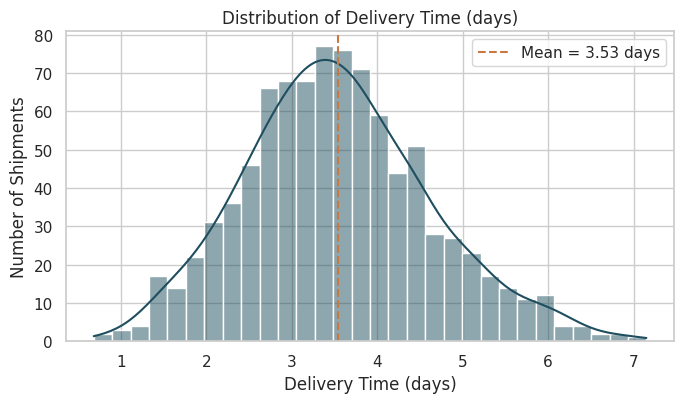

In [6]:
plt.figure(figsize=(7, 4.2))
sns.histplot(df["delivery_time_days"], bins=30, kde=True, color=ACCENT)
plt.axvline(df["delivery_time_days"].mean(), color="#C87941", linestyle="--",
            label=f"Mean = {df['delivery_time_days'].mean():.2f} days")
plt.title("Distribution of Delivery Time (days)")
plt.xlabel("Delivery Time (days)")
plt.ylabel("Number of Shipments")
plt.legend()
plt.tight_layout()
plt.show()


## Step 5: Visualization 2 — Transportation Cost by Carrier
A boxplot compares cost spread and median across carriers, surfacing outliers.

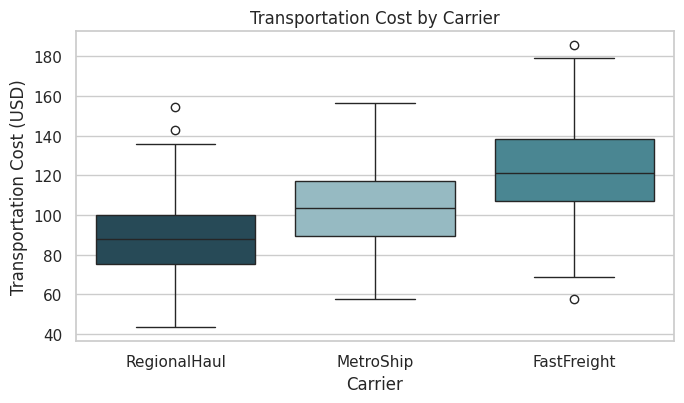

In [7]:
plt.figure(figsize=(7, 4.2))
order = df.groupby("carrier")["transportation_cost"].median().sort_values().index
sns.boxplot(data=df, x="carrier", y="transportation_cost", order=order, hue="carrier",
            palette=PALETTE, legend=False)
plt.title("Transportation Cost by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Transportation Cost (USD)")
plt.tight_layout()
plt.show()


## Step 6: Visualization 3 — Correlation Heatmap

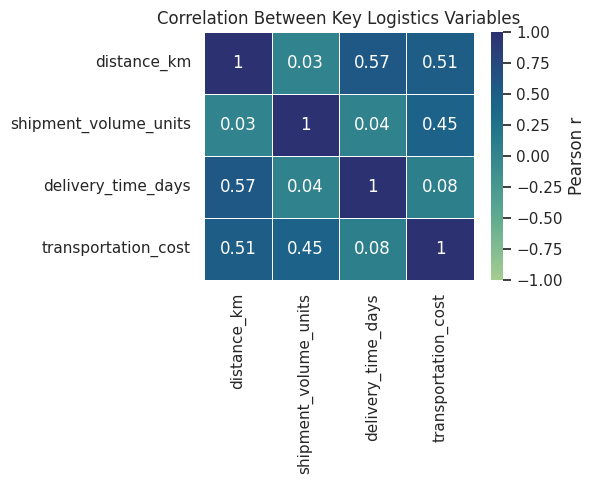

In [8]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="crest", vmin=-1, vmax=1, linewidths=0.5,
            cbar_kws={"label": "Pearson r"})
plt.title("Correlation Between Key Logistics Variables")
plt.tight_layout()
plt.show()


## Step 7: Visualization 4 — Monthly Shipment Volume vs. Average Cost
A dual-axis chart tracks two related time series (volume and cost) together.

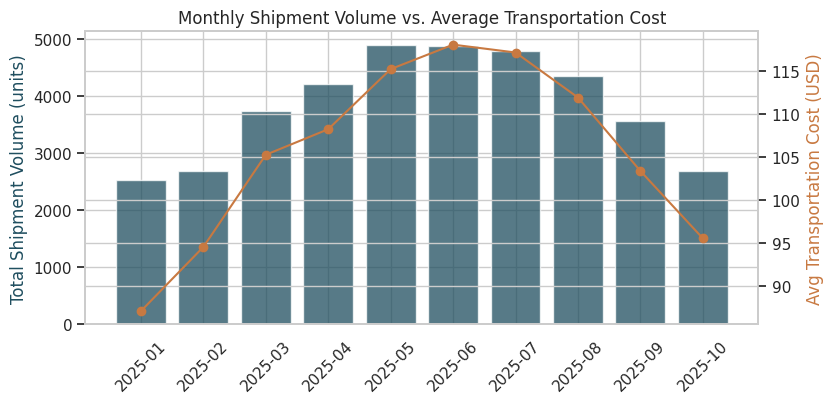

In [9]:
monthly = df.groupby("month").agg(
    total_volume=("shipment_volume_units", "sum"),
    avg_cost=("transportation_cost", "mean")
).reset_index()

fig, ax1 = plt.subplots(figsize=(8.5, 4.2))
ax1.bar(monthly["month"], monthly["total_volume"], color=ACCENT, alpha=0.75)
ax1.set_ylabel("Total Shipment Volume (units)", color=ACCENT)
ax1.tick_params(axis="x", rotation=45)
ax2 = ax1.twinx()
ax2.plot(monthly["month"], monthly["avg_cost"], color="#C87941", marker="o")
ax2.set_ylabel("Avg Transportation Cost (USD)", color="#C87941")
plt.title("Monthly Shipment Volume vs. Average Transportation Cost")
fig.tight_layout()
plt.show()


## Step 8: Visualization 5 — Distance vs. Transportation Cost
A scatter + regression line quantifies the relationship between two continuous variables.

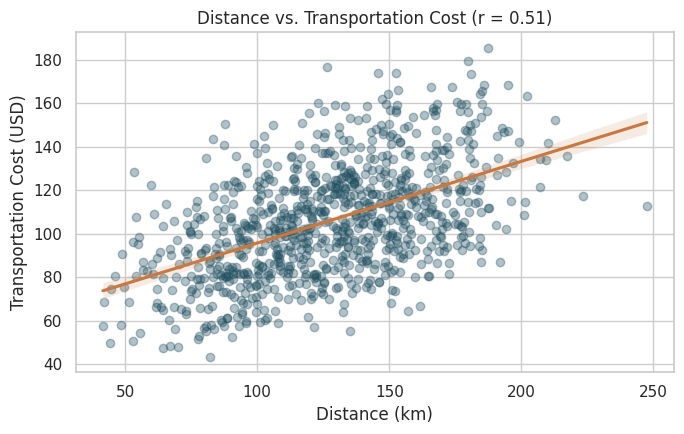

In [10]:
plt.figure(figsize=(7, 4.5))
sns.regplot(data=df, x="distance_km", y="transportation_cost",
            scatter_kws={"alpha": 0.35, "color": ACCENT}, line_kws={"color": "#C87941"})
plt.title(f"Distance vs. Transportation Cost (r = {r_dist_cost:.2f})")
plt.xlabel("Distance (km)")
plt.ylabel("Transportation Cost (USD)")
plt.tight_layout()
plt.show()


## Step 9: Visualization 6 — On-Time Delivery Rate by Warehouse
A horizontal bar chart with a target line compares a rate metric to a fixed KPI benchmark.

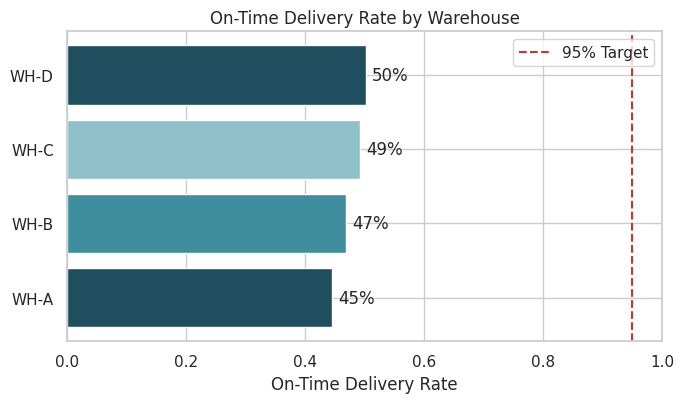

warehouse_id
WH-A    0.445255
WH-B    0.469231
WH-C    0.492462
WH-D    0.502994
Name: on_time, dtype: float64


In [11]:
otd_wh = df.groupby("warehouse_id")["on_time"].mean().sort_values()

plt.figure(figsize=(7, 4.2))
plt.barh(otd_wh.index, otd_wh.values, color=PALETTE * 2)
plt.axvline(0.95, color="#C0392B", linestyle="--", label="95% Target")
plt.xlim(0, 1)
plt.title("On-Time Delivery Rate by Warehouse")
plt.xlabel("On-Time Delivery Rate")
plt.legend()
for i, v in enumerate(otd_wh.values):
    plt.text(v + 0.01, i, f"{v:.0%}", va="center")
plt.tight_layout()
plt.show()

print(otd_wh)


## Step 10: Segment breakdown — On-time rate & cost by carrier

In [12]:
seg = df.groupby("carrier").agg(
    on_time_rate=("on_time", "mean"),
    avg_cost=("transportation_cost", "mean")
).sort_values("on_time_rate", ascending=False)
print(seg.round(3))


              on_time_rate  avg_cost
carrier                             
MetroShip            0.712   103.410
FastFreight          0.516   121.958
RegionalHaul         0.259    88.301


## Step 11: Key Insights & Recommendations (summary)

- **On-time delivery (47.3% overall)** is far below the 95% target across *every* warehouse — pointing to a systemic issue (e.g. promised windows too aggressive) rather than one location's failure.
- **Distance** (r ≈ 0.51) and **carrier choice** are the strongest, most independent drivers of transportation cost; delivery time itself barely correlates with cost (r ≈ 0.08).
- **RegionalHaul** is the cheapest carrier but by far the least reliable (~26% on-time) — worth re-evaluating for time-sensitive shipments.
- **Mid-year volume peak** (~June) coincides with the year's highest average cost, suggesting insufficient surge capacity.

### Recommendations
1. Re-negotiate or reduce reliance on RegionalHaul for time-sensitive shipments.
2. Reassess promised delivery windows network-wide rather than warehouse-by-warehouse.
3. Plan surge capacity ahead of the mid-year demand peak.
4. Build the Week 4 predictive model around **distance** and **carrier** as primary cost/delay features.


## Step 12: Save cleaned/analyzed dataset for next steps

In [13]:
df.to_csv("logistics_week3_analyzed.csv", index=False)
print("Saved logistics_week3_analyzed.csv:", df.shape)

from google.colab import files
files.download("logistics_week3_analyzed.csv")


Saved logistics_week3_analyzed.csv: (900, 12)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>